In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(55)
days = 30
rows,cols = 10,10
raw_imd_data = np.random.normal(loc=30.0, scale=1.0, size=(days,rows,cols))
raw_imd_data[10,2,4] = 40.1
raw_imd_data[18,7,8] = 41.2
raw_imd_data[25,4,3] = 40.5
print(f"dataset shape: {raw_imd_data.shape}(days,latitude grid, longitude grid)")
print(f"overall temperature range: {raw_imd_data.min():.2f}\u00b0C to {raw_imd_data.max():.2f}\u00b0C")

dataset shape: (30, 10, 10)(days,latitude grid, longitude grid)
overall temperature range: 26.88°C to 41.20°C


In [2]:
land_sea_mask = np.ones((rows,cols))
land_sea_mask[0:3,0:3] = 0.0
land_sea_mask[7:10,8:10] = 0.0
processed_imd_data = raw_imd_data.copy()
for d in range(days):
    processed_imd_data[d][land_sea_mask == 0] = np.nan
print("\nland/sea mask applied successfully!")
print("day1 grid sample(ocean pixels are NaN):\n", np.round(processed_imd_data[0], 1))


land/sea mask applied successfully!
day1 grid sample(ocean pixels are NaN):
 [[ nan  nan  nan 30.3 30.3 29.6 30.  30.3 30.9 29.6]
 [ nan  nan  nan 28.  29.5 31.4 30.3 30.7 30.9 30.7]
 [ nan  nan  nan 30.3 30.3 29.8 29.6 31.5 30.2 30.4]
 [29.8 29.5 30.4 31.  31.2 30.5 28.6 30.8 28.4 28.8]
 [29.4 29.2 30.9 30.4 30.6 29.3 30.1 31.3 28.8 29.5]
 [29.4 29.  30.2 30.7 30.3 30.1 31.6 29.3 29.9 31.3]
 [30.7 28.4 32.4 31.  30.7 29.2 29.3 31.2 30.3 30.1]
 [30.9 28.5 30.5 29.8 31.1 29.9 29.4 29.2  nan  nan]
 [31.6 29.9 30.4 28.2 29.1 33.3 30.1 30.5  nan  nan]
 [29.2 31.  31.  29.  29.4 30.  27.6 30.2  nan  nan]]


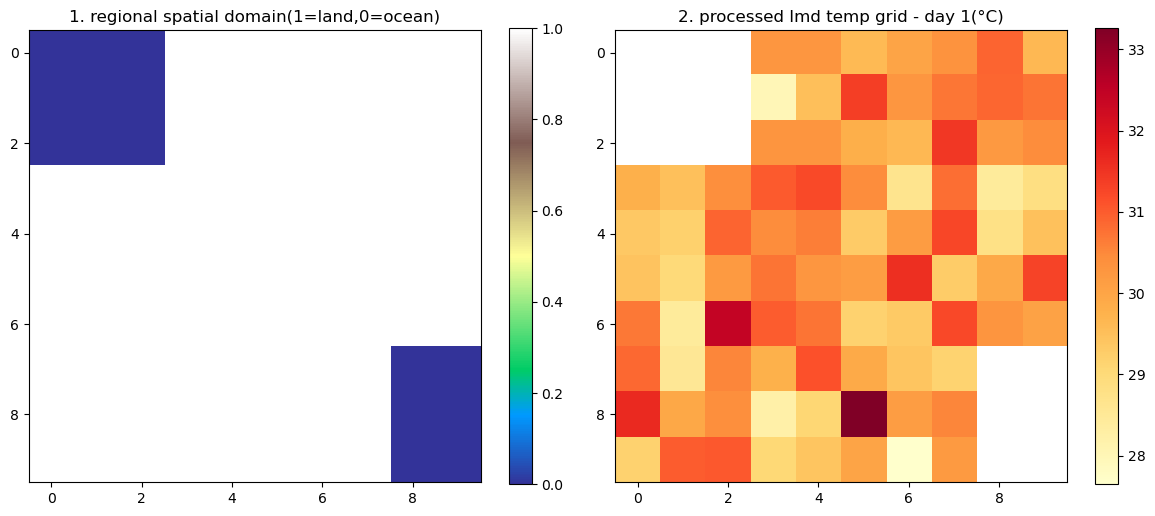

In [3]:
fig,axes = plt.subplots(1,2, figsize=(12,5))
im0 = axes[0].imshow(land_sea_mask, cmap='terrain', origin='upper')
axes[0].set_title("1. regional spatial domain(1=land,0=ocean)")
fig.colorbar(im0,ax=axes[0])
im1 = axes[1].imshow(processed_imd_data[0],cmap='YlOrRd',origin='upper')
axes[1].set_title("2. processed Imd temp grid - day 1(\u00b0C)")
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
baseline_mean = np.nanmean(processed_imd_data,axis=0)
baseline_std = np.nanstd(processed_imd_data,axis=0)
print("baseline mean map shape:",baseline_mean.shape)
print(f"overall regional mean temp:{np.nanmean(baseline_mean):.2f}\u00b0C")
print(f"overall regional std dev:{np.nanstd(baseline_std):.2f}\u00b0C")

baseline mean map shape: (10, 10)
overall regional mean temp:30.02°C
overall regional std dev:0.21°C


C:\Users\isaac\AppData\Local\Temp\ipykernel_11876\1934292588.py:3: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(processed_imd_data,axis=0)
C:\Users\isaac\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [5]:
z_score_anomalies = (processed_imd_data - baseline_mean)/baseline_std
extreme_heatwave_mask = z_score_anomalies > 1.5
heatwave_z_zones = np.where(extreme_heatwave_mask,z_score_anomalies,np.nan)
print("\nZ-score anomalies calculated successfully!")
print(f"total extreme pixel occurence over 30 days:{np.sum(extreme_heatwave_mask)}")


Z-score anomalies calculated successfully!
total extreme pixel occurence over 30 days:171


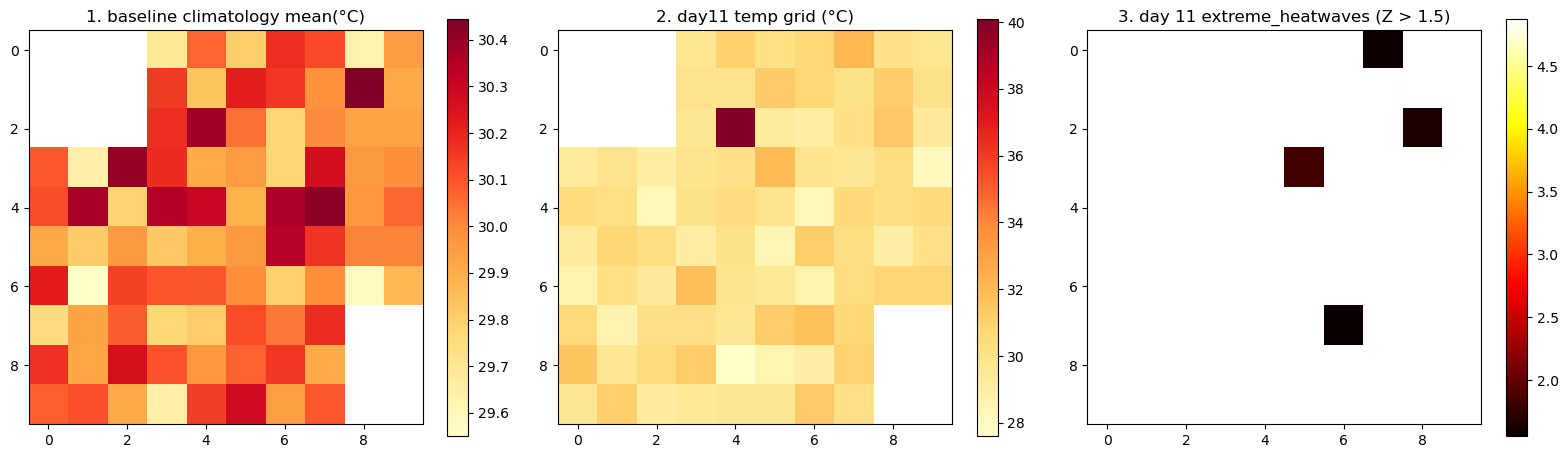

In [6]:
sample_day = 10
fig,axes = plt.subplots(1,3, figsize=(16,4.5))
im0 = axes[0].imshow(baseline_mean,cmap='YlOrRd',origin='upper')
im1 = axes[1].imshow(processed_imd_data[sample_day],cmap='YlOrRd',origin='upper')
im2 = axes[2].imshow(heatwave_z_zones[sample_day],cmap='hot',origin='upper')
axes[0].set_title("1. baseline climatology mean(\u00b0C)")
axes[1].set_title(f"2. day{sample_day+1} temp grid (\u00b0C)")
axes[2].set_title(f"3. day {sample_day+1} extreme_heatwaves (Z > 1.5)")
fig.colorbar(im0, ax=axes[0])
fig.colorbar(im1, ax=axes[1])
fig.colorbar(im2, ax=axes[2])
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
sample_day_data = processed_imd_data[10].copy()
clean_sample_data = np.nan_to_num(sample_day_data,nan=0.0)
padded_data = np.pad(clean_sample_data,pad_width=1,mode='symmetric')
print("original data shape:", clean_sample_data.shape)
print("padded data shape:", padded_data.shape)


original data shape: (10, 10)
padded data shape: (12, 12)


In [8]:
kernal_3x3 = np.ones((3,3))/9.0
smoothed_spatial_data = convolve2d(padded_data, kernal_3x3, mode='valid')
smoothed_spatial_data[land_sea_mask == 0] = np.nan
print("smoothed spatial grid shape:",smoothed_spatial_data.shape)
print("\nsmoothing applied successfully")

smoothed spatial grid shape: (10, 10)

smoothing applied successfully


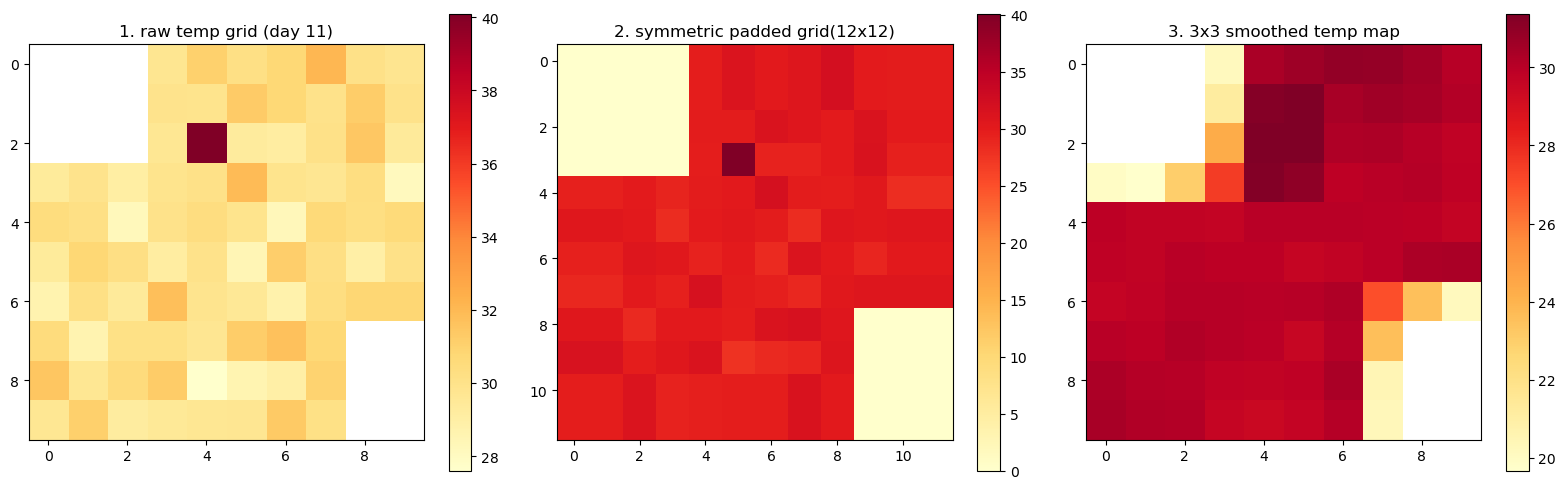

In [9]:
fig,axes = plt.subplots(1,3, figsize=(16,5))
im0 = axes[0].imshow(processed_imd_data[10],cmap='YlOrRd',origin='upper')
axes[0].set_title("1. raw temp grid (day 11)")
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(padded_data, cmap='YlOrRd', origin='upper')
axes[1].set_title("2. symmetric padded grid(12x12)")
fig.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(smoothed_spatial_data,cmap='YlOrRd',origin='upper')
axes[2].set_title("3. 3x3 smoothed temp map")
fig.colorbar(im2, ax=axes[2])
plt.tight_layout()
plt.show()


In [10]:
import numpy as np#day-58
import matplotlib.pyplot as plt
p90_threshold = np.nanpercentile(processed_imd_data, 90)
print(F"regional 90th percentile threshold temperature: {p90_threshold:.2f}\u00b0C")
print(f"90% of the days, temperature were below this threshold!")

regional 90th percentile threshold temperature: 31.26°C
90% of the days, temperature were below this threshold!


In [11]:
p90_mask = processed_imd_data > p90_threshold
day11_raw = processed_imd_data[10]
day11_hotspots = np.where(day11_raw > p90_threshold, day11_raw, np.nan)
total_hotspot_occurrences = np.sum(p90_mask)
print(F"total extreme heatwave hotspot occurrences(across 30 days): {total_hotspot_occurrences} grid pixels")

total extreme heatwave hotspot occurrences(across 30 days): 255 grid pixels


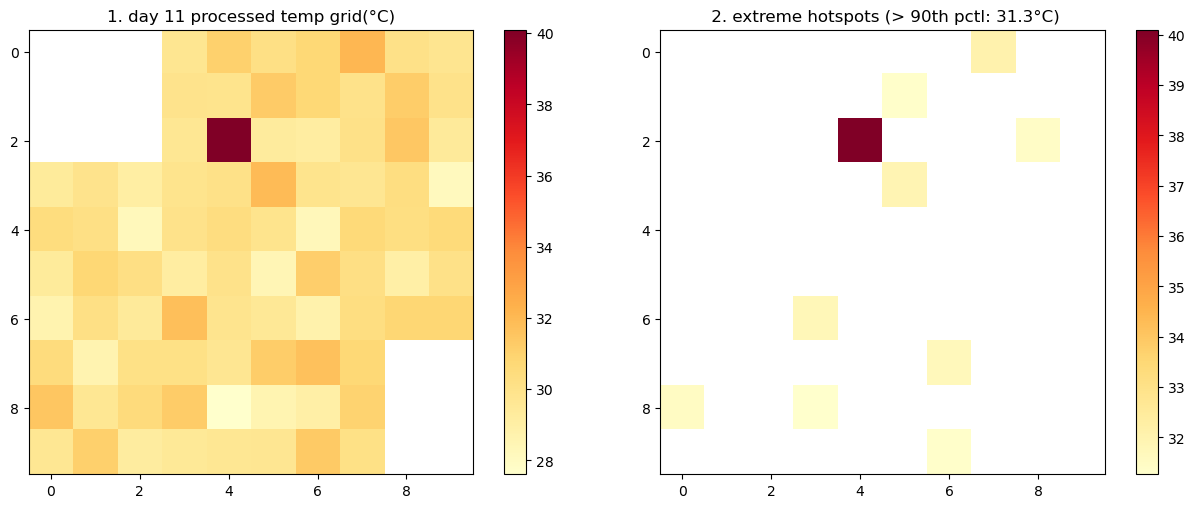

In [12]:
fig,axes = plt.subplots(1,2, figsize=(13,5))
im0 = axes[0].imshow(day11_raw, cmap='YlOrRd', origin='upper')
axes[0].set_title("1. day 11 processed temp grid(\u00b0C)")
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(day11_hotspots, cmap='YlOrRd', origin='upper')
axes[1].set_title(F" 2. extreme hotspots (> 90th pctl: {p90_threshold:.1f}\u00b0C)")
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

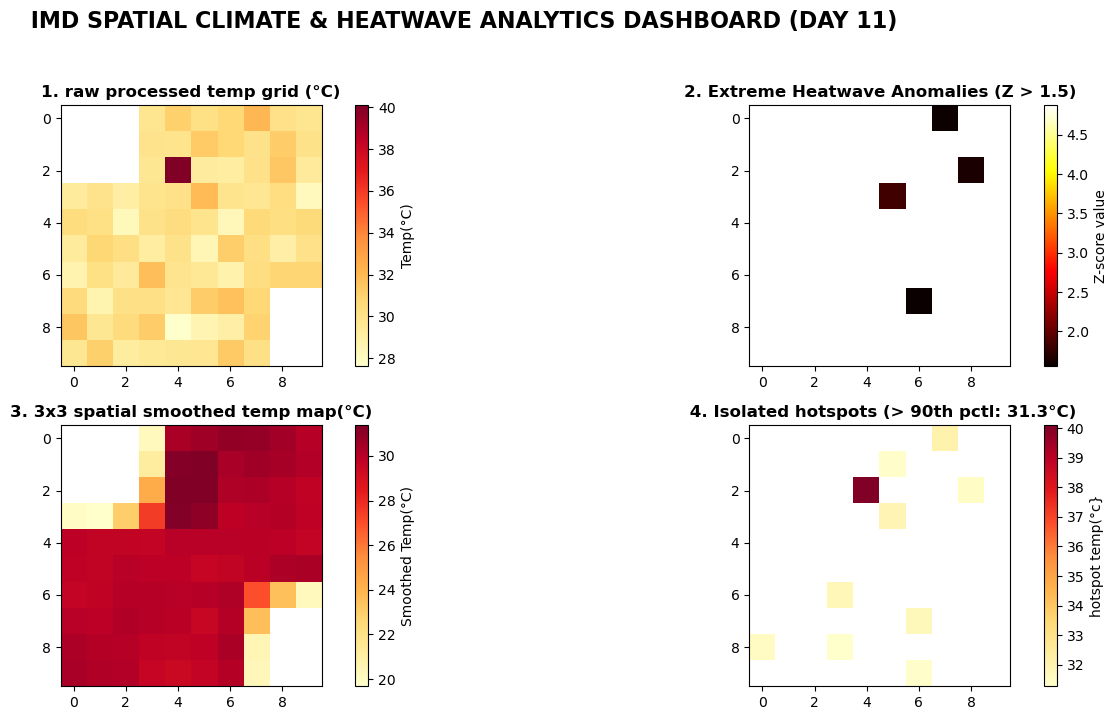

n CONGRATULATIONS THALA! IMD CLIMATE PROJECT IS 100% COMPLETE!
dashboard image saved as 'Imd_Heatwave_Executive_Dashboard.png'


In [16]:
import numpy as np
import matplotlib.pyplot as plt
target_day = 10
day_num = target_day + 1
fig,axes = plt.subplots(2,2, figsize=(14,11))
plt.suptitle(f" IMD SPATIAL CLIMATE & HEATWAVE ANALYTICS DASHBOARD (DAY {day_num})",fontsize=16, fontweight='bold',y=0.95)
im0 = axes[0,0].imshow(processed_imd_data[target_day], cmap='YlOrRd', origin='upper')
axes[0,0].set_title("1. raw processed temp grid (\u00b0C)", fontsize=12, fontweight='bold')
fig.colorbar(im0, ax=axes[0,0], label="Temp(\u00b0C)")
im1 = axes[0,1].imshow(heatwave_z_zones[target_day], cmap='hot', origin='upper')
axes[0,1].set_title(F"2. Extreme Heatwave Anomalies (Z > 1.5)",  fontsize=12, fontweight='bold')
fig.colorbar(im1, ax=axes[0,1], label="Z-score value")
im2 = axes[1,0].imshow(smoothed_spatial_data, cmap='YlOrRd', origin='upper')
axes[1,0].set_title("3. 3x3 spatial smoothed temp map(\u00b0C)", fontsize=12, fontweight='bold')
fig.colorbar(im2, ax=axes[1,0], label="Smoothed Temp(\u00b0C)")
im3 = axes[1,1].imshow(day11_hotspots, cmap='YlOrRd', origin='upper')
axes[1,1].set_title(f" 4. Isolated hotspots (> 90th pctl: {p90_threshold:.1f}\u00b0C)", fontsize=12, fontweight='bold')
fig.colorbar(im3, ax=axes[1,1], label="hotspot temp(\u00b0c}")
plt.tight_layout(rect=[0, 0.3, 1, 0.93])
plt.savefig("Imd_Heatwave_Executive_Dashboard.png", dpi=300, bbox_inches='tight')
plt.show()
print("n CONGRATULATIONS THALA! IMD CLIMATE PROJECT IS 100% COMPLETE!")
print("dashboard image saved as 'Imd_Heatwave_Executive_Dashboard.png'")